Fetching individual images via streamed remote zipfile...
[SUCCESS] Downloaded: 98_6c_PMC5383004_pone.0172624.g006_3.jpg to derm_train_images/pubmed/98_6c_PMC5383004_pone.0172624.g006_3.jpg
[SUCCESS] Downloaded: 00_39_PMC10381143_jimaging-09-00148-g011_1.jpg to derm_train_images/pubmed/00_39_PMC10381143_jimaging-09-00148-g011_1.jpg
[SUCCESS] Downloaded: 0d_59_PMC4458964_IJD_60_321e_g003_0.png to derm_train_images/pubmed/0d_59_PMC4458964_IJD_60_321e_g003_0.png
[SUCCESS] Downloaded: e2_67_PMC3445843_1471_5945_12_7_7.png to derm_train_images/pubmed/e2_67_PMC3445843_1471_5945_12_7_7.png
[SUCCESS] Downloaded: 89_38_PMC3350198_CRIM.PEDIATRICS2012_152602.002_1.png to derm_train_images/pubmed/89_38_PMC3350198_CRIM.PEDIATRICS2012_152602.002_1.png
[SUCCESS] Downloaded: 0b_33_PMC3804142_CRIM.DENTISTRY2013_672383.001_0.png to derm_train_images/pubmed/0b_33_PMC3804142_CRIM.DENTISTRY2013_672383.001_0.png
[SUCCESS] Downloaded: 2281_1.png to derm_train_images/IIYI/2281_1.png
[SUCCESS] Downloaded: 1408

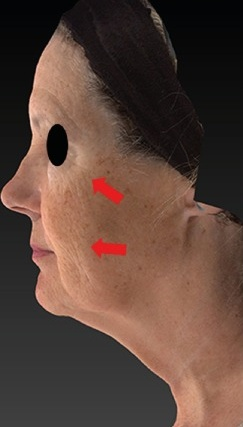

In [ ]:
import io
import os
import zipfile
from PIL import Image
from huggingface_hub import HfFileSystem

# Initialize the file system 
fs = HfFileSystem()

pubmed_filenames = [
    "98_6c_PMC5383004_pone.0172624.g006_3.jpg",
    "00_39_PMC10381143_jimaging-09-00148-g011_1.jpg",
    "0d_59_PMC4458964_IJD_60_321e_g003_0.png",
    "e2_67_PMC3445843_1471_5945_12_7_7.png",
    "89_38_PMC3350198_CRIM.PEDIATRICS2012_152602.002_1.png",
    "0b_33_PMC3804142_CRIM.DENTISTRY2013_672383.001_0.png"
]

IIYI_filenames = [
    "2281_1.png",
    "14083_1.png",
]

youtube_filenames = [
    "OzBKmWt9zWo_frame_8071_0_0.jpg"
]


repo_id = "datasets/redlessone/Derm1M"
downloaded_images = {}

print("Fetching individual images via streamed remote zipfile...")

download_tasks = {
    "pubmed": pubmed_filenames,
    "IIYI": IIYI_filenames,
    "youtube": youtube_filenames
}

for category, filenames in download_tasks.items():
    zip_name = f"{category}.zip"
    remote_zip_path = f"{repo_id}/{zip_name}"
    
    try:
        with fs.open(remote_zip_path, "rb") as remote_file:
            with zipfile.ZipFile(remote_file) as zf:
                
                for filename in filenames:
                    internal_path = f"{filename}"
                    
                    try:
                        with zf.open(internal_path) as img_file:
                            img = Image.open(io.BytesIO(img_file.read())).convert("RGB")
                            
                            downloaded_images[filename] = img
                            
                            local_save_path = f"derm_train_images/{category}/{filename}"
                            os.makedirs(os.path.dirname(local_save_path), exist_ok=True)
                            img.save(local_save_path)
                            
                            print(f"[SUCCESS] Downloaded: {filename} to {local_save_path}")
                            
                    except KeyError:
                        print(f"[ERROR] File '{internal_path}' does not exist inside '{zip_name}'.")
                    except Exception as e:
                        print(f"[ERROR] Failed to download {internal_path}: {e}")
                        
    except Exception as e:
        print(f"[ERROR] Could not open remote zip '{remote_zip_path}': {e}")

if downloaded_images:
    first_image = list(downloaded_images.values())[0]
    display(first_image)

In [5]:
import os
from datasets import load_dataset

# 1. Load the dataset in streaming mode (bypasses full download)
ds = load_dataset("marmal88/skin_cancer", streaming=True)
split_name = 'train' if 'train' in ds else list(ds.keys())[0]
data_stream = ds[split_name]

# 2. Extract and print all labels from the dataset features (metadata is loaded immediately)
print("=== Dataset Labels ===")
label_col_name = None

for col_name, feature in data_stream.features.items():
    if getattr(feature, 'names', None) is not None:
        print(f"Labels found in the '{col_name}' column:")
        print(feature.names)
        label_col_name = col_name
        break

if not label_col_name:
    # Fallback to look for common text label columns if ClassLabel isn't used
    for fallback_col in ['dx', 'label', 'cell_type', 'diagnosis']:
        if fallback_col in data_stream.features:
            print(f"Dataset contains a label column named: '{fallback_col}'")
            label_col_name = fallback_col
            break

# 3. Create the directory for the images
output_dir = "ham_images" 
os.makedirs(output_dir, exist_ok=True)

# 4. Stream, shuffle, and take 5 images
print(f"\n=== Saving 5 Random Images to {output_dir}/ ===")

# shuffle() with a buffer loads 'buffer_size' elements into memory and samples from them
sampled_stream = data_stream.shuffle(buffer_size=1000, seed=1).take(5)

for i, sample in enumerate(sampled_stream):
    if 'image' in sample:
        img = sample['image']
        
        # Get label value
        label_val = sample.get(label_col_name, "unknown") if label_col_name else "unknown"
        
        # If it's a ClassLabel integer, map it back to the string name
        if isinstance(label_val, int) and label_col_name and hasattr(data_stream.features[label_col_name], 'names'):
            label_val = data_stream.features[label_col_name].names[label_val]
            
        # Clean label string for valid filename
        safe_label = str(label_val).replace(" ", "_").replace("/", "-")
        
        filename = f"sample_{i}_{safe_label}.jpg"
        save_path = os.path.join(output_dir, filename)
        
        # Save RGB image
        img.convert("RGB").save(save_path)
        print(f"Saved: {save_path}")
    else:
        print("Error: Could not find an 'image' column in the sample.")

=== Dataset Labels ===
Dataset contains a label column named: 'dx'

=== Saving 5 Random Images to ham_images/ ===
Saved: ham_images/sample_0_melanocytic_Nevi.jpg
Saved: ham_images/sample_1_melanocytic_Nevi.jpg
Saved: ham_images/sample_2_melanoma.jpg
Saved: ham_images/sample_3_melanoma.jpg
Saved: ham_images/sample_4_melanocytic_Nevi.jpg


In [4]:
import open_clip

# List all available models and pretraining datasets
available_models = open_clip.list_models()
print([m for m in available_models if 'coca' in m.lower()])

# For a specific model, check available pretrained weights
pretrained_options = open_clip.list_pretrained('coca_ViT-B-32')
print(pretrained_options)

['coca_base', 'coca_roberta-ViT-B-32', 'coca_ViT-B-32', 'coca_ViT-L-14']
['RN50:openai', 'RN50:yfcc15m', 'RN50:cc12m', 'RN101:openai', 'RN101:yfcc15m', 'RN50x4:openai', 'RN50x16:openai', 'RN50x64:openai', 'ViT-B-32:openai', 'ViT-B-32:laion400m_e31', 'ViT-B-32:laion400m_e32', 'ViT-B-32:laion2b_e16', 'ViT-B-32:laion2b_s34b_b79k', 'ViT-B-32:datacomp_xl_s13b_b90k', 'ViT-B-32:datacomp_m_s128m_b4k', 'ViT-B-32:commonpool_m_clip_s128m_b4k', 'ViT-B-32:commonpool_m_laion_s128m_b4k', 'ViT-B-32:commonpool_m_image_s128m_b4k', 'ViT-B-32:commonpool_m_text_s128m_b4k', 'ViT-B-32:commonpool_m_basic_s128m_b4k', 'ViT-B-32:commonpool_m_s128m_b4k', 'ViT-B-32:datacomp_s_s13m_b4k', 'ViT-B-32:commonpool_s_clip_s13m_b4k', 'ViT-B-32:commonpool_s_laion_s13m_b4k', 'ViT-B-32:commonpool_s_image_s13m_b4k', 'ViT-B-32:commonpool_s_text_s13m_b4k', 'ViT-B-32:commonpool_s_basic_s13m_b4k', 'ViT-B-32:commonpool_s_s13m_b4k', 'ViT-B-32:metaclip_400m', 'ViT-B-32:metaclip_fullcc', 'ViT-B-32-256:datacomp_s34b_b86k', 'ViT-B-16:op